<a href="https://colab.research.google.com/github/AniTigerSib/AI-Methods/blob/main/AIlab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Реализация классификации состояния растений по изображениям посредством CNN

Вариант 7

In [1]:
import os
import json
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms.v2 as tfs
import torchvision

## Task 1

In [2]:
tsr = torch.ones(1, 7, 777, 777).cuda()
print(f"Исходный тензор: {tsr.shape}")

# свертка
conv = nn.Conv2d(
    in_channels=7,      # число входных каналов
    out_channels=77,    # число фильтров
    kernel_size=7,      # размер ядра
    stride=7,           # шаг свёртки
    padding=7           # отступ
).cuda()

tsr_conv = conv(tsr)
print(f"После свёртки: {tsr_conv.shape}")

# пулинг
pool = nn.MaxPool2d(
    kernel_size=7,      # размер окна объединения
    stride=7            # шаг объединения
).cuda()

tsr_pool = pool(tsr_conv)
print(f"После пулинга: {tsr_pool.shape}")

Исходный тензор: torch.Size([1, 7, 777, 777])
После свёртки: torch.Size([1, 77, 113, 113])
После пулинга: torch.Size([1, 77, 16, 16])


## Task 2

In [3]:
from google.colab import drive
import os
import zipfile

# Монтируем Google Drive
drive.mount('/content/drive', force_remount=True)

# 2. Указываем путь к ZIP-архиву на вашем Диске
ZIP_PATH = '/content/drive/MyDrive/plant_diseases_zip.zip'
EXTRACT_TO = '/content/datasets/plants'

# 3. Создаём папку для распаковки
os.makedirs(EXTRACT_TO, exist_ok=True)

# 4. Распаковываем архив
print(f"Распаковка {os.path.basename(ZIP_PATH)}...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_TO)

print("Готово!")

# 5. Проверяем структуру
print(f"\nСодержимое {EXTRACT_TO}:")
for root, dirs, files in os.walk(EXTRACT_TO):
    level = root.replace(EXTRACT_TO, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    sub_indent = ' ' * 2 * (level + 1)
    for file in files[:3]:  # Показываем первые 3 файла в папке
        print(f"{sub_indent}{file}")
    if len(files) > 3:
        print(f"{sub_indent}... и ещё {len(files) - 3} файлов")

Mounted at /content/drive
Распаковка plant_diseases_zip.zip...
Готово!

Содержимое /content/datasets/plants:
plants/
  plant_diseases/
    index.txt
    .DS_Store
    (1).DS_Store
    Test/
      Black_rot/
        53744.jpg
        52923.jpg
        53549.jpg
        ... и ещё 247 файлов
      Powdery_mildew/
        47854.jpg
        75241.jpg
        47601.jpg
        ... и ещё 247 файлов
      Bacterial_spot/
        65007.jpg
        79855.jpg
        79214.jpg
        ... и ещё 247 файлов
      Rust/
        49972.jpg
        103593.jpg
        49345.jpg
        ... и ещё 247 файлов
      Healthy/
        73779.jpg
        95433.jpg
        73743.jpg
        ... и ещё 247 файлов
      Late_blight/
        82636.jpg
        82494.jpg
        83385.jpg
        ... и ещё 247 файлов
    Train/
      Black_rot/
        53511.jpg
        53688.jpg
        53752.jpg
        ... и ещё 997 файлов
      Powdery_mildew/
        47228.jpg
        75527.jpg
        76595.jpg
        ... и ещё

In [4]:
DATA_ROOT = '/content/datasets/plants/plant_diseases'

# Проверка структуры
print(f"Train classes: {os.listdir(os.path.join(DATA_ROOT, 'Train'))}")
print(f"Test classes: {os.listdir(os.path.join(DATA_ROOT, 'Test'))}")

Train classes: ['Black_rot', 'Powdery_mildew', 'Bacterial_spot', 'Rust', 'Healthy', 'Late_blight']
Test classes: ['Black_rot', 'Powdery_mildew', 'Bacterial_spot', 'Rust', 'Healthy', 'Late_blight']


In [5]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torch

# === Трансформации для обучения ===
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),           # Приведение к единому размеру
    transforms.RandomHorizontalFlip(p=0.5),  # Аугментация
    transforms.RandomRotation(15),           # Аугментация
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # Аугментация
    transforms.ToTensor(),                   # Конвертация в тензор
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Нормализация (ImageNet stats)
                         std=[0.229, 0.224, 0.225])
])

# === Трансформации для валидации/теста ===
test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# === Кастомный ImageFolder для обучения ===
class PlantDatasetTrain(ImageFolder):
    """Dataset для обучения с аугментациями"""

    def __init__(self, root, transform=None, target_transform=None):
        super().__init__(root=root,
                        transform=transform or train_transform,
                        target_transform=target_transform)
        self.classes = self.classes
        self.class_to_idx = self.class_to_idx

    def __getitem__(self, index):
        # Получаем базовый элемент
        sample, target = super().__getitem__(index)
        # Можно добавить дополнительную логику при необходимости
        return sample, target

# === Кастомный ImageFolder для теста ===
class PlantDatasetTest(ImageFolder):
    """Dataset для тестирования без аугментаций"""

    def __init__(self, root, transform=None, target_transform=None):
        super().__init__(root=root,
                        transform=transform or test_transform,
                        target_transform=target_transform)

    def __getitem__(self, index):
        sample, target = super().__getitem__(index)
        # Возвращаем также путь к изображению для анализа ошибок
        path = self.samples[index][0]
        return sample, target, path

In [6]:
from torch.utils.data import DataLoader

# Пути к подпапкам
train_dir = os.path.join(DATA_ROOT, 'Train')
test_dir = os.path.join(DATA_ROOT, 'Test')

# Создаём экземпляры датасетов
train_dataset = PlantDatasetTrain(root=train_dir)
test_dataset = PlantDatasetTest(root=test_dir)

# Создаём DataLoaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,            # Перемешивание для обучения
    num_workers=2,           # Кол-во потоков для загрузки данных
    pin_memory=True          # Ускорение передачи на GPU
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Проверка
print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")
print(f"Classes: {train_dataset.classes}")
print(f"Class mapping: {train_dataset.class_to_idx}")

Train batches: 188, Test batches: 47
Classes: ['Bacterial_spot', 'Black_rot', 'Healthy', 'Late_blight', 'Powdery_mildew', 'Rust']
Class mapping: {'Bacterial_spot': 0, 'Black_rot': 1, 'Healthy': 2, 'Late_blight': 3, 'Powdery_mildew': 4, 'Rust': 5}


### Визуализация батча для проверки

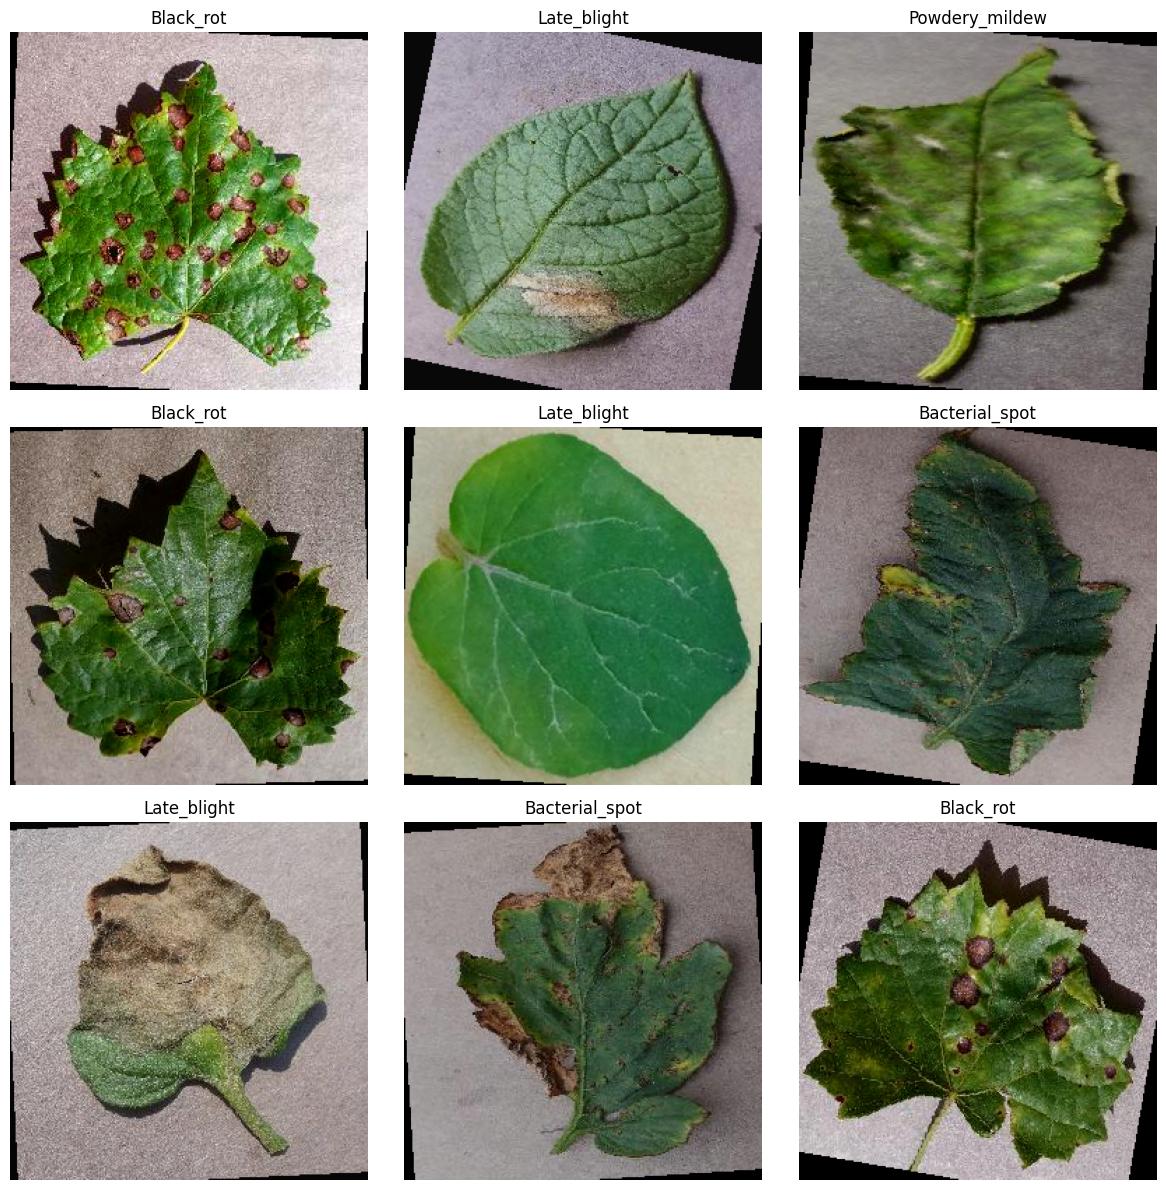

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def denormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Обратная нормализация для визуализации"""
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor.clip(0, 1)

# Получаем один батч
images, labels = next(iter(train_loader))

# Визуализируем первые 9 изображений
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    if i < len(images):
        img = denormalize(images[i]).permute(1, 2, 0).cpu().numpy()
        ax.imshow(img)
        ax.set_title(f"{train_dataset.classes[labels[i]]}")
        ax.axis('off')
plt.tight_layout()
plt.show()

### Работа с предобученной моделью

In [8]:
import torchvision.models as models

googlenet_weights = models.GoogLeNet_Weights.DEFAULT
tsfs = googlenet_weights.transforms()
model = models.googlenet(weights=googlenet_weights).cuda()

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 197MB/s]


In [9]:
# Замораживаем все параметры базовой модели
for param in model.parameters():
    param.requires_grad = False

In [10]:
# Заменяем финальный классификатор
# GoogLeNet имеет: model.fc -> Linear(1024, 1000)
num_features = model.fc.in_features  # 1024
num_classes = 6
model.fc = nn.Linear(num_features, num_classes).cuda()

In [11]:
# Размораживаем ТОЛЬКО новый слой (опционально можно разморозить часть backbone)
for param in model.fc.parameters():
    param.requires_grad = True

In [12]:
# 5. Проверяем, какие параметры будут обучаться
trainable_params = [p for p in model.parameters() if p.requires_grad]
print(f"Trainable parameters: {len(trainable_params)}")
print(f"FC layer weights shape: {model.fc.weight.shape}")

Trainable parameters: 2
FC layer weights shape: torch.Size([6, 1024])


In [13]:
# Заменяем вспомогательные aux классификаторы тоже
if model.aux1 is not None:
    model.aux1.fc2 = nn.Linear(1024, num_classes).cuda()
    for param in model.aux1.fc2.parameters():
        param.requires_grad = True

if model.aux2 is not None:
    model.aux2.fc2 = nn.Linear(1024, num_classes).cuda()
    for param in model.aux2.fc2.parameters():
        param.requires_grad = True

In [14]:
# Оптимизатор только для обучаемых параметров!
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3  # Более высокий LR для нового слоя
)

# Функция потерь
criterion = nn.CrossEntropyLoss()

In [15]:
def train_epoch(model, loader, optimizer, criterion, device='cuda'):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # GoogLeNet возвращает GoogLeNetOutputs (logits, aux1, aux2)
        # Если aux отключены — получаем просто logits
        if isinstance(outputs, models.GoogLeNetOutputs):
            logits = outputs.logits
        else:
            logits = outputs

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        # Статистика
        running_loss += loss.item()
        _, predicted = logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return {
        'loss': running_loss / len(loader),
        'acc': 100. * correct / total
    }

def evaluate(model, loader, criterion, device='cuda'):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels, test in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            if isinstance(outputs, models.GoogLeNetOutputs):
                logits = outputs.logits
            else:
                logits = outputs

            loss = criterion(logits, labels)

            running_loss += loss.item()
            _, predicted = logits.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return {
        'loss': running_loss / len(loader),
        'acc': 100. * correct / total
    }

In [16]:
for epoch in range(3):
  res = train_epoch(model, train_loader, optimizer, criterion)
  print(f"Epoch: {epoch}\n\tLoss: {res['loss']}\n\tAcc: {res['acc']}\n\n")

Epoch: 0
	Loss: 0.8756952379295166
	Acc: 76.76666666666667


Epoch: 1
	Loss: 0.4324404281029042
	Acc: 89.08333333333333


Epoch: 2
	Loss: 0.3225719166245866
	Acc: 91.76666666666667




In [17]:
evaluate(model, test_loader, criterion)

{'loss': 0.22017248743709097, 'acc': 95.2}

In [18]:
import torch
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    accuracy_score,
    cohen_kappa_score,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Глобальные хранилища для истории
history = defaultdict(list)

In [26]:
def evaluate_advanced(model, loader, criterion, class_names, device='cuda'):
    """
    Полная оценка модели с расширенными метриками.
    """
    model.eval()
    running_loss = 0.0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels, test in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            # Обработка вывода GoogLeNet
            if hasattr(outputs, 'logits'):
                logits = outputs.logits
            else:
                logits = outputs

            loss = criterion(logits, labels)
            running_loss += loss.item()

            # Сохраняем метрики
            probs = torch.nn.functional.softmax(logits, dim=1)
            _, preds = torch.max(probs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Конвертация в numpy
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # --- Расчет метрик ---
    metrics = {
        'loss': running_loss / len(loader),
        'accuracy': accuracy_score(all_labels, all_preds),
    }

    # 1. Precision, Recall, F1 (по классам и средние)
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels, all_preds, average=None, zero_division=0
    )

    metrics['precision_macro'] = np.mean(precision)
    metrics['recall_macro'] = np.mean(recall)
    metrics['f1_macro'] = np.mean(f1)

    metrics['precision_micro'] = precision_recall_fscore_support(
        all_labels, all_preds, average='micro', zero_division=0
    )[0]
    metrics['f1_micro'] = precision_recall_fscore_support(
        all_labels, all_preds, average='micro', zero_division=0
    )[2]

    # 2. Cohen's Kappa (учитывает случайное угадывание)
    metrics['kappa'] = cohen_kappa_score(all_labels, all_preds)

    # 3. Top-K Accuracy (полезно для большого числа классов)
    metrics['top3_acc'] = top_k_accuracy(all_probs, all_labels, k=3)
    metrics['top5_acc'] = top_k_accuracy(all_probs, all_labels, k=5)

    # 4. По классам (для детального отчета)
    metrics['per_class'] = {
        class_names[i]: {
            'precision': precision[i],
            'recall': recall[i],
            'f1': f1[i],
            'support': support[i]
        }
        for i in range(len(class_names))
    }

    # 5. Матрица ошибок
    metrics['confusion_matrix'] = confusion_matrix(all_labels, all_preds)

    # 6. ROC-AUC (One-vs-Rest для многоклассовой)
    try:
        metrics['roc_auc_macro'] = roc_auc_score(
            all_labels, all_probs,
            average='macro',
            multi_class='ovr'
        )
    except ValueError:
        metrics['roc_auc_macro'] = 0.0

    return metrics, all_preds, all_labels, all_probs

In [20]:
def top_k_accuracy(probs, labels, k=3):
    """Вычисляет Top-K точность"""
    top_k_preds = np.argsort(probs, axis=1)[:, -k:]
    correct = 0
    for i, label in enumerate(labels):
        if label in top_k_preds[i]:
            correct += 1
    return 100. * correct / len(labels)

def print_classification_report(metrics, class_names):
    """Красивый вывод отчета в консоль"""
    print("\n" + "="*60)
    print("📊 ОТЧЕТ ПО КЛАССИФИКАЦИИ")
    print("="*60)
    print(f"Accuracy:       {metrics['accuracy']*100:.2f}%")
    print(f"Top-3 Accuracy: {metrics['top3_acc']:.2f}%")
    print(f"F1 Macro:       {metrics['f1_macro']*100:.2f}%")
    print(f"Cohen's Kappa:  {metrics['kappa']:.4f}")
    print(f"ROC-AUC Macro:  {metrics['roc_auc_macro']:.4f}")
    print("-"*60)
    print("📈 ПО КЛАССАМ:")
    print("-"*60)
    print(f"{'Class':<20} {'Precision':<10} {'Recall':<10} {'F1':<10} {'Count':<10}")
    print("-"*60)
    for cls_name, cls_metrics in metrics['per_class'].items():
        print(f"{cls_name:<20} {cls_metrics['precision']:<10.3f} {cls_metrics['recall']:<10.3f} {cls_metrics['f1']:<10.3f} {int(cls_metrics['support']):<10}")
    print("="*60 + "\n")

def plot_confusion_matrix(cm, class_names, save_path=None):
    """Визуализация матрицы ошибок"""
    plt.figure(figsize=(12, 10))
    # Нормализация для процентов
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Нормализованная матрица ошибок')
    plt.ylabel('Истинный класс')
    plt.xlabel('Предсказанный класс')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Возврат к оригиналу для сохранения
    plt.close()

In [29]:
class_names = ['bacterial spot', 'black rot', 'healthylate blight', 'powdery mildew', 'rust']
metrics, p1, p2, p3 = evaluate_advanced(model, test_loader, criterion, class_names)

In [30]:
print_classification_report(metrics, class_names)


📊 ОТЧЕТ ПО КЛАССИФИКАЦИИ
Accuracy:       95.20%
Top-3 Accuracy: 99.93%
F1 Macro:       95.22%
Cohen's Kappa:  0.9424
ROC-AUC Macro:  0.9983
------------------------------------------------------------
📈 ПО КЛАССАМ:
------------------------------------------------------------
Class                Precision  Recall     F1         Count     
------------------------------------------------------------
bacterial spot       0.951      0.932      0.941      250       
black rot            0.988      0.968      0.978      250       
healthylate blight   0.944      0.952      0.948      250       
powdery mildew       0.889      0.928      0.908      250       
rust                 0.992      0.940      0.965      250       



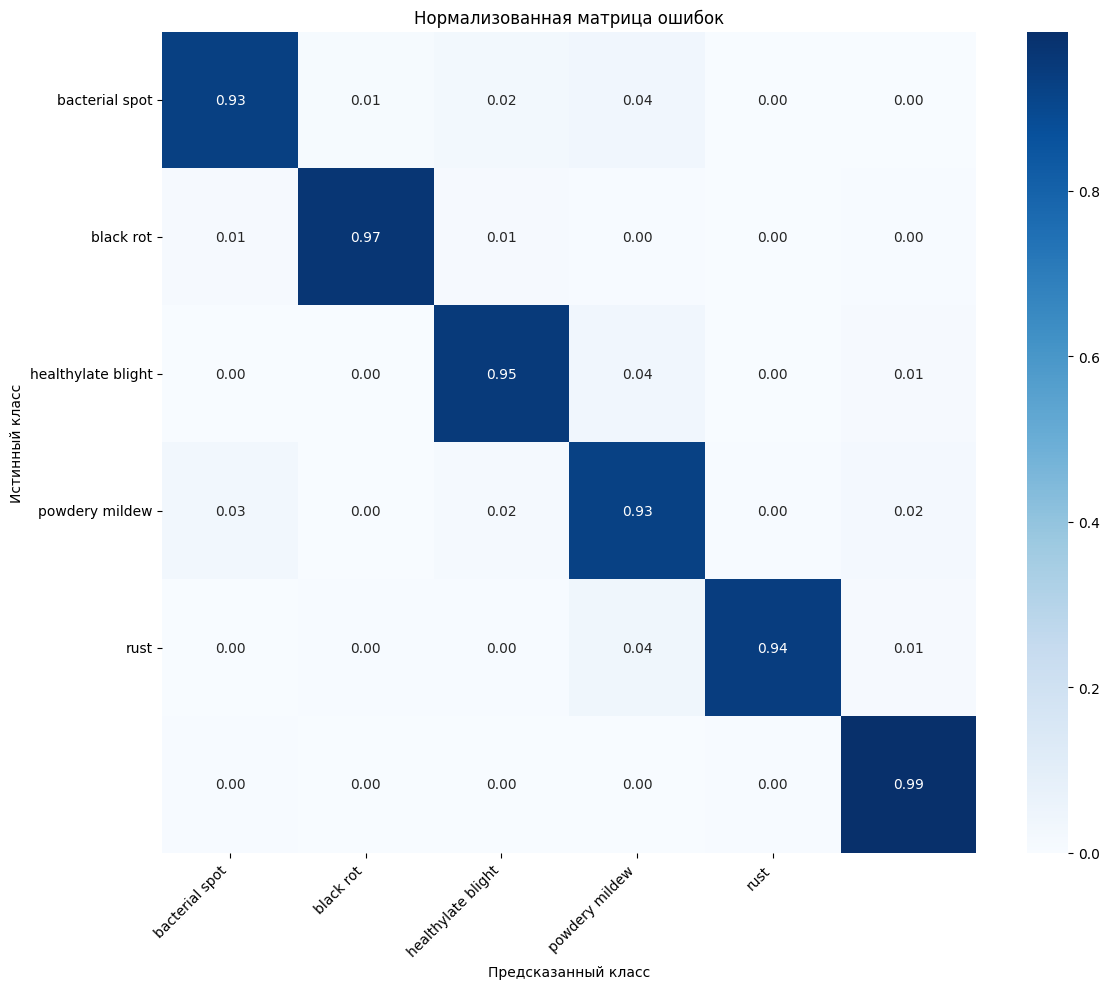

In [31]:
plot_confusion_matrix(metrics['confusion_matrix'], class_names)